ЗАВДАННЯ 1
Місто: Харків
Модель: стохастична, статична, описова/прогнозна
Балансова: ні
Оптимізаційна: ні
Імітаційна: ні

ЗАВДАННЯ 2
    місяць  температура  споживання_МВтгод
0        1         -6.2             4098.0
1        2         -3.9             3990.0
2        3          0.8             3696.0
3        4          9.1             3406.0
4        5         16.1             3038.0
5        6         21.0             2936.0
6        7         23.5             2778.0
7        8         22.1             2804.0
8        9         16.5             2999.0
9       10          8.2             3430.0
10      11          1.6             3733.0
11      12         -4.2             3919.0

Модель: споживання = 3783.23 + (-43.71) * температура
a = 3783.23
b = -43.71

ЗАВДАННЯ 3
    місяць  температура  споживання_МВтгод  передбачення  залишок
0        1         -6.2             4098.0       4054.21    43.79
1        2         -3.9             3990.0       3953.69    36.31
2        3          

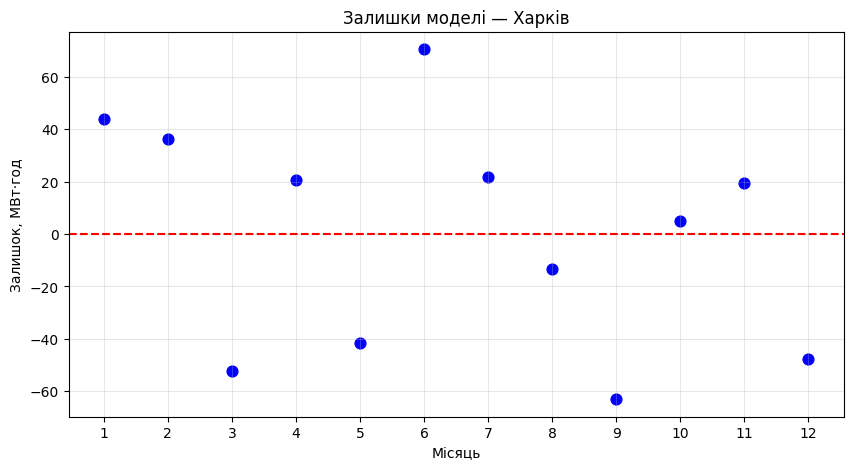


ЗАВДАННЯ 4
Верифікація:
Температура січня = -6.2 °C
Розрахунок вручну = 4054.21
Розрахунок кодом = 4054.21
Результат перевірки: True

Валідація:
Для валідації потрібні нові незалежні дані, наприклад дані наступного року.

ЗАВДАННЯ 5
Модель є достатньо адекватною.
R² високе, а залишки розташовані навколо нуля.
Додаткове ускладнення моделі не потрібне.


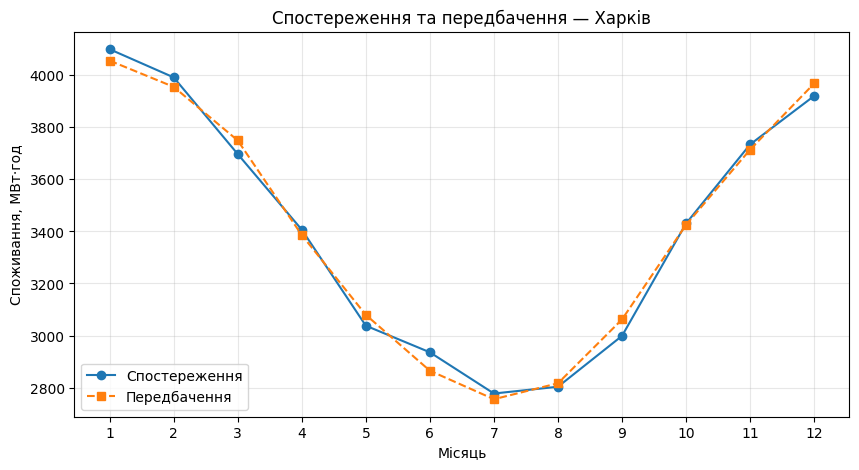

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ЗАВДАННЯ 1. Класифікація моделі
# ============================================================

print("ЗАВДАННЯ 1")
print("Місто: Харків")
print("Модель: стохастична, статична, описова/прогнозна")
print("Балансова: ні")
print("Оптимізаційна: ні")
print("Імітаційна: ні")


# ============================================================
# ЗАВДАННЯ 2. Побудова моделі на власних даних
# ============================================================

np.random.seed(4)

city = "Харків"
base_temp = 8.8
amplitude = 15
base_consumption = 3400
k = 45
noise_sd = 55

months = np.arange(1, 13)

temp = base_temp + amplitude * np.cos(
    (months - 7) / 12 * 2 * np.pi
)

temp = np.round(
    temp + np.random.normal(0, 0.5, size=12),
    1
)

consumption = (
    base_consumption
    - k * (temp - base_temp)
    + np.random.normal(0, noise_sd, size=12)
)

consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption
})

print("\nЗАВДАННЯ 2")
print(city_data)

b, a = np.polyfit(
    city_data["температура"],
    city_data["споживання_МВтгод"],
    1
)

city_data["передбачення"] = (
    a + b * city_data["температура"]
)

print(f"\nМодель: споживання = {a:.2f} + ({b:.2f}) * температура")
print(f"a = {a:.2f}")
print(f"b = {b:.2f}")


# ============================================================
# ЗАВДАННЯ 3. Залишки та оцінка адекватності
# ============================================================

residuals = (
    city_data["споживання_МВтгод"]
    - city_data["передбачення"]
)

city_data["залишок"] = residuals

ss_res = (residuals ** 2).sum()

ss_tot = (
    (
        city_data["споживання_МВтгод"]
        - city_data["споживання_МВтгод"].mean()
    ) ** 2
).sum()

r_squared = 1 - ss_res / ss_tot

print("\nЗАВДАННЯ 3")

print(
    city_data[
        [
            "місяць",
            "температура",
            "споживання_МВтгод",
            "передбачення",
            "залишок"
        ]
    ].round(2)
)

print(f"\nR² = {r_squared:.4f}")


# Графік залишків

plt.figure(figsize=(10, 5))

plt.scatter(
    city_data["місяць"],
    city_data["залишок"],
    color="blue",
    s=60
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Місяць")
plt.ylabel("Залишок, МВт·год")
plt.title("Залишки моделі — Харків")
plt.xticks(months)
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# ЗАВДАННЯ 4. Верифікація і валідація
# ============================================================

print("\nЗАВДАННЯ 4")

# Верифікація для січня
t = city_data.loc[0, "температура"]

manual_prediction = a + b * t
code_prediction = city_data.loc[0, "передбачення"]

print("Верифікація:")
print(f"Температура січня = {t} °C")
print(f"Розрахунок вручну = {manual_prediction:.2f}")
print(f"Розрахунок кодом = {code_prediction:.2f}")
print(
    f"Результат перевірки: "
    f"{np.isclose(manual_prediction, code_prediction)}"
)

print("\nВалідація:")
print(
    "Для валідації потрібні нові незалежні дані, "
    "наприклад дані наступного року."
)


# ============================================================
# ЗАВДАННЯ 5. Вдосконалення моделі
# ============================================================

print("\nЗАВДАННЯ 5")

if r_squared >= 0.9:
    print("Модель є достатньо адекватною.")
    print("R² високе, а залишки розташовані навколо нуля.")
    print("Додаткове ускладнення моделі не потрібне.")
else:
    print("Модель потребує вдосконалення.")


# ============================================================
# ДОДАТКОВО. Графік спостережень і передбачень
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    city_data["місяць"],
    city_data["споживання_МВтгод"],
    "o-",
    label="Спостереження"
)

plt.plot(
    city_data["місяць"],
    city_data["передбачення"],
    "s--",
    label="Передбачення"
)

plt.xlabel("Місяць")
plt.ylabel("Споживання, МВт·год")
plt.title("Спостереження та передбачення — Харків")
plt.xticks(months)
plt.grid(alpha=0.3)
plt.legend()

plt.show()


Контрольні питання
1. Чи можете чітко розмежувати верифікацію й валідацію на прикладі саме вашої моделі?
Верифікація моєї моделі — це перевірка правильності реалізації формули та коду. Наприклад, для січня я можу вручну підставити температуру в отриману формулу
a
+
b
T
 і перевірити, чи збігається результат із тим, що обчислив Python.

Валідація — це перевірка того, наскільки модель відповідає новим, незалежним даним. Для цього доцільно використати, наприклад, дані про споживання електроенергії Харкова за наступний рік, які не використовувалися під час підбору коефіцієнтів
a
 і
b
.

2. За якими незалежними ознаками класифікується ваша модель і чому ці ознаки не суперечать одна одній?
Моя модель є стохастичною, оскільки містить випадкову складову — шум.

Вона є статичною, тому що споживання конкретного місяця залежить від температури цього самого місяця і не залежить від споживання попереднього місяця.

За типом задачі модель є описовою/прогнозною статистичною моделлю. Вона не є балансовою, оскільки не описує закон збереження; не є оптимізаційною, оскільки не шукає найкраще рішення; і не є імітаційною, оскільки не моделює систему покроково в часі.

Ці ознаки не суперечать одна одній, тому що характеризують різні властивості моделі.

3. Що конкретно показує отримане у вас
R
2
, і чи високе
R
2
 саме по собі доводить, що модель правильна?
Для мого варіанта отримано
R
2
≈
0.992
. Це означає, що приблизно 99,2% варіації споживання електроенергії в цих 12 спостереженнях пояснюється лінійною залежністю від температури.

Однак високе
R
2
 саме по собі не доводить, що модель є правильною в усіх ситуаціях або придатною для екстраполяції за межі спостережуваного діапазону температур. Для цього потрібно додатково аналізувати залишки та перевіряти модель на нових незалежних даних.

4. Чому структура залишків інформативніша, ніж лише сумарна величина відхилень?
Сама величина залишків показує, наскільки сильно модель помиляється, але не показує характер цієї помилки.

Якщо залишки випадково розкидані навколо нуля, це свідчить, що модель не має очевидної систематичної помилки. Якщо ж залишки утворюють тренд або певну закономірність, це означає, що модель не враховує певну залежність.

У моєму випадку залишки мають як додатні, так і від'ємні значення та не демонструють вираженої систематичної закономірності. Разом із високим
R
2
 це свідчить про достатню адекватність лінійної моделі для цього набору даних.


